# **Online Retail Analysis & Customer Segmentation**

This notebook explores an end-to-end analysis of an online retail dataset, starting from raw transactional data and progressing through data cleaning, exploratory data analysis, and customer-level feature engineering. The focus is on understanding sales performance across products, regions, and time, while also ensuring data quality through systematic validation of key fields such as invoices and product codes.

Beyond descriptive analysis, the notebook builds a customer-centric view of the business using RFM (Recency, Frequency, Monetary) modeling. These features are used to segment customers based on their purchasing behavior, enabling the identification of high-value customers, at-risk groups, and potential growth opportunities. Finally, clustering techniques are applied to group customers into meaningful segments, which are then interpreted into actionable business categories to support targeted marketing and retention strategies.

# **Table of Contents**

---

## **Dataset 1: Exploratory Data Analysis (EDA)**

> ### **Customer Overview**
- Customer Distribution Across Segments  
- Most Frequent Customers  
- High Repeat Customers (20+ Orders)  
- Total Sales per Customer  
- Highest Value Customers by Revenue  
- Identifying Customers for Targeted Marketing  

> ### **Revenue & Customer Behaviour**
- Revenue Contribution by Customer Segment  
- Customer Preferences for Shipping Modes  

> ### **Geographic Analysis**
- Customer Distribution Across Top States  
- Sales Contribution by Top States  
- Sales Contribution by Top Cities  

> ### **Product Analysis**
- Which Categories Have the Widest Product Range?  
- Which Product Categories Generate the Most Revenue?  
- Which Sub-Categories Generate the Most Revenue?  

> ### **Time-Based Sales Trends**
- How Have Sales Changed Over Time?  
- Quarterly Revenue Breakdown  
- Sales Breakdown by Month  

---

## **Dataset 2: Customer Segmentation (RFM Analysis + Clustering)**

> ### **Data Cleaning & Feature Engineering**
- Data Cleaning  
- Feature Engineering  
- Deriving Revenue for Each Order Line  

> ### **RFM Customer Profiling**
- Customer Purchase Behavior Summary (RFM)  
- Customer Recency Analysis  
- Distribution of RFM Metrics  
- RFM Outlier Analysis  
- Customer Distribution in RFM Space  
- 3D Visualization of RFM Metrics (Scaled)  

> ### **K-Means Clustering (Segmentation)**
- K-Means Cluster Evaluation  
- Customer Segmentation Using RFM Clusters  

> ### **Cluster Interpretation & Business Insights**
- RFM Profile Comparison Across Customer Clusters  
- Translating Clusters into Customer Segments  
- Understanding Customer Segments: Size and Value Comparison  

## **Importing Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Format floating-point values with two decimal places for clearer output
pd.options.display.float_format = "{:,.2f}".format

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Remove warnings
import warnings
warnings.filterwarnings('ignore')

## **Dataset 1: Exploration Data Analysis**

In [2]:
# Load dataset
df = pd.read_csv('superstore.csv', encoding='latin1', engine='python')

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [3]:
# Dataset structure summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
# Dataset dimensions (observations, features)
df.shape

(9994, 21)

In [5]:
# Missing value count per column
df.isnull().sum()  # alternative: df.isna().mean() * 100 for percentage

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
# Check for duplicate rows
df.duplicated().any()  # alternative: df.duplicated().sum() for count

np.False_

In [7]:
# Unique values per categorical column
for i in ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']:
    print(f'The unique values for {i} are: {df[i].unique()}')

The unique values for Ship Mode are: ['Second Class' 'Standard Class' 'First Class' 'Same Day']
The unique values for Segment are: ['Consumer' 'Corporate' 'Home Office']
The unique values for Region are: ['South' 'West' 'Central' 'East']
The unique values for Category are: ['Furniture' 'Office Supplies' 'Technology']
The unique values for Sub-Category are: ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


### **Customer Distribution Across Segments**

In [8]:
# Customer count by segment
num_of_cust = df['Segment'].value_counts().reset_index(name='Number of Customers')

# Display result
num_of_cust

,Segment,Number of Customers
0,Consumer,5191
1,Corporate,3020
2,Home Office,1783


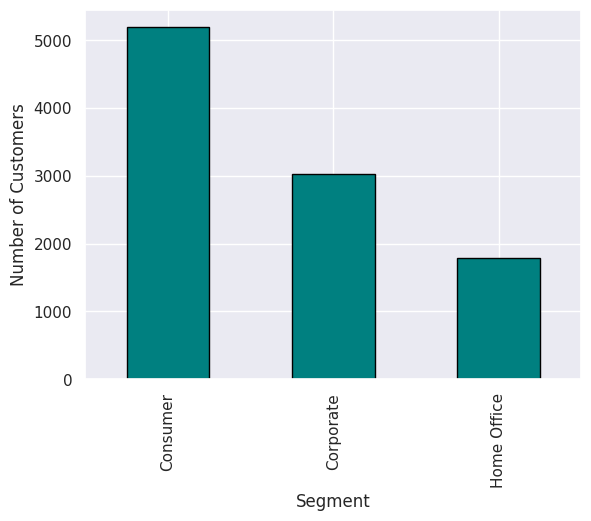

In [9]:
# Segment distribution (count)
sns.set_theme(style="darkgrid")

df['Segment'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.ylabel('Number of Customers')

# Segment distribution table
num_of_cust = df.groupby('Segment').size().reset_index(name='Number of Customers')

([<matplotlib.patches.Wedge at 0x7e1dfc2f8620>,
 [Text(-0.06704023782468152, 1.0979551933081833, 'Consumer'),
  Text(-0.5268842285426254, -0.9656049967316049, 'Corporate'),
  Text(0.9316986876474538, -0.5847542692755757, 'Home Office')],
 [Text(-0.03656740244982628, 0.5988846508953727, '51.9%'),
  Text(-0.28739139738688657, -0.5266936345808754, '30.2%'),
  Text(0.5081992841713383, -0.318956874150314, '17.8%')])

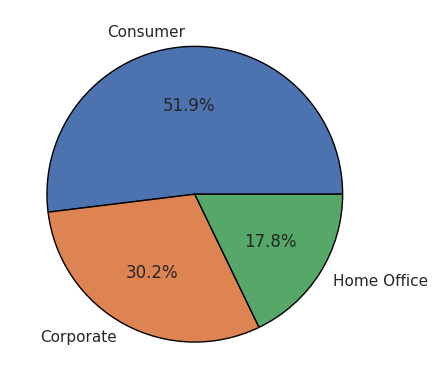

In [10]:
# Segment share distribution
# colors = sns.color_palette('pastel')
plt.pie(num_of_cust['Number of Customers'], labels=num_of_cust['Segment'], wedgeprops={'edgecolor': 'black'}, autopct='%1.1f%%')

## Key Findings

- **Consumer** is the largest segment with **51.9%** of total customers.
- **Corporate** contributes **30.2%**, making it the second-largest segment.
- **Home Office** has the smallest share at **17.8%**.

## Insights

- The business is heavily driven by the **Consumer** segment.
- **Corporate** customers represent a strong secondary market with growth potential.
- **Home Office** is underrepresented and may offer opportunities for targeted marketing and expansion.

### **Revenue Contribution by Customer Segment**

In [11]:
# Total sales by segment
sales_per_segment = df.groupby('Segment')['Sales'].sum().reset_index(name='Sales')

# Display aggregated sales
sales_per_segment

,Segment,Sales
0,Consumer,"1,161,401.34"
1,Corporate,"706,146.37"
2,Home Office,"429,653.15"


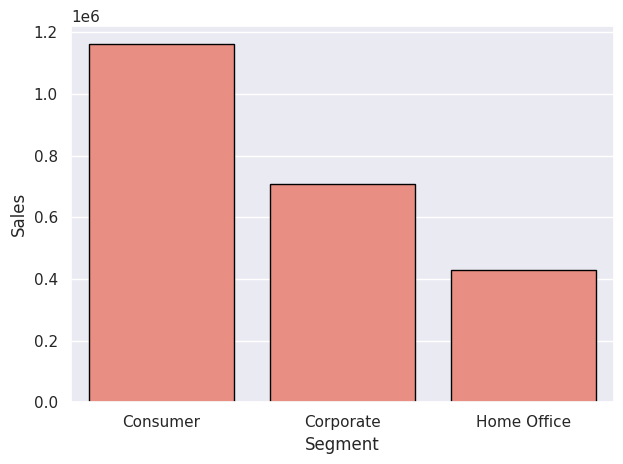

In [12]:
# Sales by segment (bar chart)
sns.barplot(data=sales_per_segment, x='Segment', y='Sales', color='salmon', edgecolor='black')

# Layout adjustment
plt.tight_layout()

# Show plot
plt.show()

In [13]:
# or
# sns.barplot(data = sales_per_segment, x = 'Segment', y='Sales', estimator='sum', color='seagreen')
# plt.tight_layout()
# plt.show()

([<matplotlib.patches.Wedge at 0x7e1dfc36db50>,
 [Text(-0.019255799354537615, 1.099831448082486, 'Consumer'),
  Text(-0.5936664965175892, -0.9260454043471796, 'Corporate'),
  Text(0.9155113397403079, -0.6097860172280986, 'Home Office')],
 [Text(-0.010503163284293245, 0.5999080625904468, '50.6%'),
  Text(-0.323818089009594, -0.5051156750984616, '30.7%'),
  Text(0.4993698216765315, -0.33261055485169005, '18.7%')])

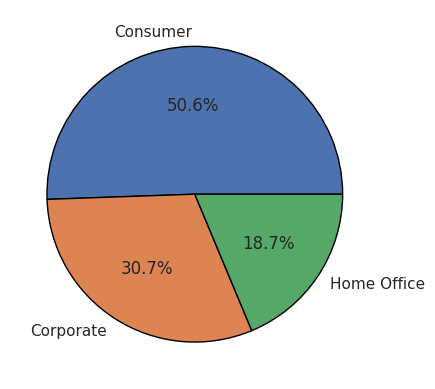

In [14]:
# Sales share by segment
plt.pie(sales_per_segment['Sales'], labels=sales_per_segment['Segment'], wedgeprops={'edgecolor': 'black'}, autopct='%1.1f%%')

## Key Findings

- **Consumer** generates the highest sales contribution at **50.6%**.
- **Corporate** contributes **30.7%** of total sales.
- **Home Office** accounts for **18.7%**, the smallest share.

## Insights

- Sales are primarily driven by the **Consumer** segment, contributing over half of total sales.
- The **Corporate** segment is a significant revenue source and offers strong growth opportunities.
- The **Home Office** segment contributes the least, indicating potential for targeted marketing and sales strategies.

### **Most Frequent Customers**

In [15]:
# Top customers by order frequency
customer_order_freq = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Order ID'] \
    .count().reset_index(name='Total_Orders') \
    .sort_values(by='Total_Orders', ascending=False).head(5)

# Display top customers
customer_order_freq

,Customer ID,Customer Name,Segment,Total_Orders
787,WB-21850,William Brown,Consumer,37
482,MA-17560,Matt Abelman,Home Office,34
387,JL-15835,John Lee,Consumer,34
606,PP-18955,Paul Prost,Home Office,34
257,EH-13765,Edward Hooks,Corporate,32


### **High Repeat Customers (20+ Orders)**

In [16]:
# Filter high repeat customers (20+ orders)
repeat_customers = customer_order_freq.query('Total_Orders >= 20') \
    .sort_values('Total_Orders', ascending=False)

# Display repeat customers
repeat_customers

,Customer ID,Customer Name,Segment,Total_Orders
787,WB-21850,William Brown,Consumer,37
482,MA-17560,Matt Abelman,Home Office,34
387,JL-15835,John Lee,Consumer,34
606,PP-18955,Paul Prost,Home Office,34
257,EH-13765,Edward Hooks,Corporate,32


### **Total Sales per Customer**

In [17]:
# Total sales per customer
customer_sales = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Sales'] \
    .sum().reset_index()

# Display customer sales
customer_sales.head()

,Customer ID,Customer Name,Segment,Sales
0,AA-10315,Alex Avila,Consumer,"5,563.56"
1,AA-10375,Allen Armold,Consumer,"1,056.39"
2,AA-10480,Andrew Allen,Consumer,"1,790.51"
3,AA-10645,Anna Andreadi,Consumer,"5,086.93"
4,AB-10015,Aaron Bergman,Consumer,886.16


### **Highest Value Customers by Revenue**

In [18]:
# Top customers by total sales
top_spenders = customer_sales.sort_values('Sales', ascending=False)

# Display top 5 spenders
top_spenders.head(5)

,Customer ID,Customer Name,Segment,Sales
700,SM-20320,Sean Miller,Home Office,"25,043.05"
741,TC-20980,Tamara Chand,Corporate,"19,052.22"
621,RB-19360,Raymond Buch,Consumer,"15,117.34"
730,TA-21385,Tom Ashbrook,Home Office,"14,595.62"
6,AB-10105,Adrian Barton,Consumer,"14,473.57"


### **Identifying Customers for Targeted Marketing**

In [19]:
# Customer contact flag based on sales threshold
top_spenders['To Contact?'] = top_spenders['Sales'].apply(
    lambda x: 'Send targeted discounts and loyalty points!' if x > 15000 else 'No need to contact'
)

# Display updated table
top_spenders.head()

,Customer ID,Customer Name,Segment,Sales,To Contact?
700,SM-20320,Sean Miller,Home Office,"25,043.05",Send targeted discounts and loyalty points!
741,TC-20980,Tamara Chand,Corporate,"19,052.22",Send targeted discounts and loyalty points!
621,RB-19360,Raymond Buch,Consumer,"15,117.34",Send targeted discounts and loyalty points!
730,TA-21385,Tom Ashbrook,Home Office,"14,595.62",No need to contact
6,AB-10105,Adrian Barton,Consumer,"14,473.57",No need to contact


In [20]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87


### **Customer Preferences for Shipping Modes**

In [21]:
# Shipping mode distribution
shipping_model = df['Ship Mode'].value_counts().reset_index(name='Count')

# Display results
shipping_model

,Ship Mode,Count
0,Standard Class,5968
1,Second Class,1945
2,First Class,1538
3,Same Day,543


([<matplotlib.patches.Wedge at 0x7e1dfc39eba0>,
 [Text(-0.3305657516984502, 1.0491550332548754, 'Standard Class'),
  Text(-0.3760776532491148, -1.0337144667298794, 'Second Class'),
  Text(0.7465350845565396, -0.8078894525404824, 'First Class'),
  Text(1.0840145085529618, -0.18684899048879292, 'Same Day')],
 [Text(-0.18030859183551826, 0.5722663817753865, '59.7%'),
  Text(-0.20513326540860807, -0.5638442545799341, '19.5%'),
  Text(0.4072009552126579, -0.44066697411299033, '15.4%'),
  Text(0.5912806410288882, -0.10191763117570521, '5.4%')])

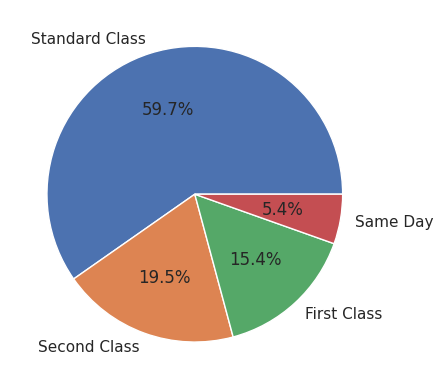

In [22]:
# Shipping mode share
plt.pie(shipping_model['Count'], labels=shipping_model['Ship Mode'], autopct='%1.1f%%')

## Key Findings

- **Standard Class** dominates shipping mode usage with **59.7%**, making it the most frequently used option.
- **Second Class** accounts for **19.5%**, the second‑largest share.
- **First Class** contributes **15.4%** of shipments.
- **Same Day** shipping represents the smallest portion at **5.4%**.

## Insights

- The overwhelming reliance on **Standard Class** suggests customers prioritise cost‑effective shipping over speed.
- **Second Class** and **First Class** together make up roughly **35%**, indicating a moderate demand for faster delivery options.
- The very low **Same Day** share implies limited customer need for urgent deliveries or potentially higher pricing barriers.
- Opportunities may exist to **promote premium shipping tiers** or **optimise Standard Class operations**, given its heavy usage.

In [23]:
# State-wise record count
state = df['State'].value_counts().reset_index(name='Count')

# Preview top states
state.head()

,State,Count
0,California,2001
1,New York,1128
2,Texas,985
3,Pennsylvania,587
4,Washington,506


### **Customer Distribution Across Top States**

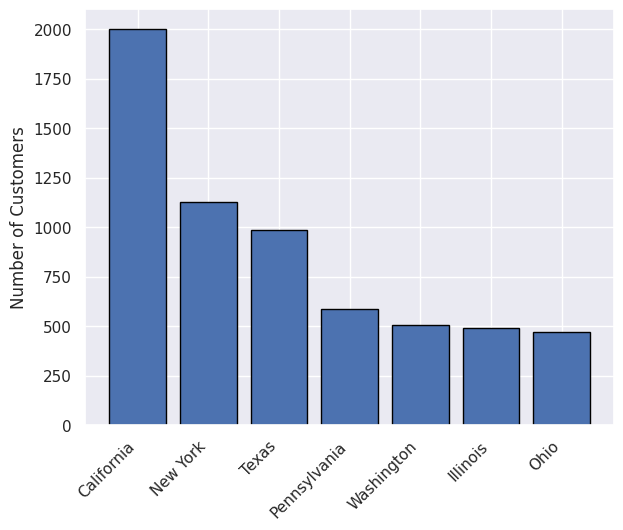

In [24]:
# Top 7 states by record count
top_states = state.sort_values('Count', ascending=False).head(7)

# Bar chart of top states
plt.bar(top_states['State'], top_states['Count'], edgecolor='black')

plt.ylabel('Number of Customers')

# Layout adjustment
plt.tight_layout()

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

# Render plot
plt.show()

## Key Findings

- **California** has the highest number of customers, reaching up to **2000**, far more than any other state.
- **New York** and **Texas** follow with approximately **1100** and **1000** customers, forming a strong secondary tier.
- **Pennsylvania**, **Washington**, **Illinois**, and **Ohio** each have **500–600** customers, representing a noticeably smaller customer base.

## Insights

- The large customer concentration in **California** indicates it is the primary market driver and a critical region for customer‑focused strategies.
- **New York** and **Texas** show strong customer presence, suggesting they are valuable markets with potential for further expansion.
- The group of states with **500-600** customers reflects a long tail of moderate‑sized markets that could benefit from targeted outreach or regional campaigns.
- The steep drop after the top three states highlights an **uneven customer distribution**, where a few states dominate customer volume while others remain underdeveloped.

In [25]:
# Column data types
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [26]:
# Total sales by state
state_sales = df.groupby('State')['Sales'].sum().reset_index(name='total_sales') \
    .sort_values('total_sales', ascending=False)

# Top states by sales
state_sales.head()

,State,total_sales
3,California,"457,687.63"
30,New York,"310,876.27"
41,Texas,"170,188.05"
45,Washington,"138,641.27"
36,Pennsylvania,"116,511.91"


### **Sales Contribution by Top States**

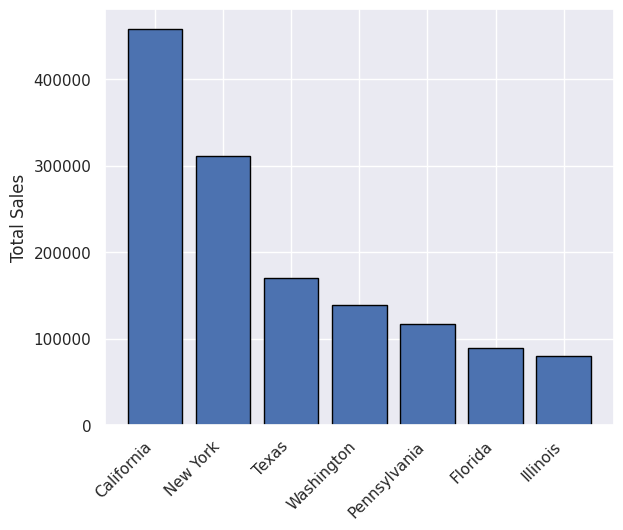

In [27]:
# Top 7 states by total sales
top_state_sales = state_sales.head(7)

# Bar chart for state-wise sales
plt.bar(top_state_sales['State'], top_state_sales['total_sales'], edgecolor='black')

plt.ylabel("Total Sales")

# Layout adjustment
plt.tight_layout()

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

# Render plot
plt.show()

## Key Findings (by State)

- **California** records the highest total sales, approaching **$450,000**, making it the strongest state‑level market.
- **New York** and **Texas** follow as the next highest‑performing states, with substantial but clearly lower sales than California.
- **Washington**, **Pennsylvania**, **Florida**, and **Illinois** form a mid‑to‑lower tier, each generating noticeably smaller sales volumes.

## Insights

- California stands out as the **top‑performing state**, indicating a highly concentrated revenue base and strong customer activity.
- The solid performance of New York and Texas positions them as **key secondary states** with meaningful sales potential.
- The remaining states show **moderate sales levels**, suggesting opportunities for targeted regional strategies to boost performance.
- The sharp gap between California and the rest highlights a **state‑level imbalance**, where focusing on high‑value states while nurturing underperforming ones could optimise overall growth.

In [28]:
# Total sales by city
city_sales = df.groupby('City')['Sales'].sum().reset_index(name='total_sales') \
    .sort_values('total_sales', ascending=False)

# Top cities by sales
city_sales.head()

,City,total_sales
329,New York City,"256,368.16"
266,Los Angeles,"175,851.34"
452,Seattle,"119,540.74"
438,San Francisco,"112,669.09"
374,Philadelphia,"109,077.01"


### **Sales Contribution by Top Cities**

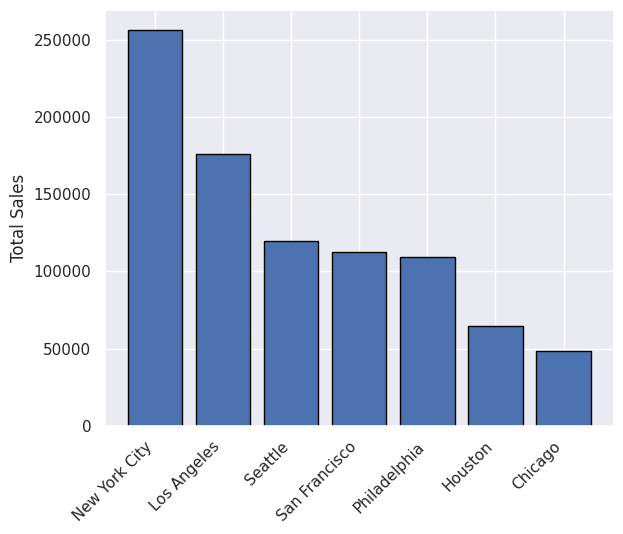

In [29]:
# Top 7 cities by total sales
top_city_sales = city_sales.head(7)

# Bar chart for city-wise sales
plt.bar(top_city_sales['City'], top_city_sales['total_sales'], edgecolor='black')

plt.ylabel('Total Sales')

# Layout adjustment
plt.tight_layout()

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

# Axis label
plt.ylabel("Total Sales")

# Render plot
plt.show()

## Key Findings (by City)

- **New York City** has the highest total sales, reaching close to **$250,000**, making it the strongest city‑level market.
- **Los Angeles** follows as the second‑highest contributor with a substantial sales volume.
- **Seattle** and **San Francisco** form a solid mid‑tier, each generating meaningful but lower sales than the top two cities.
- **Philadelphia**, **Houston**, and **Chicago** show comparatively lower sales, forming the bottom tier among the cities analysed.

## Insights

- New York City stands out as the **top‑performing city**, indicating a highly concentrated customer and revenue base.
- Los Angeles, while behind NYC, remains a **key strategic market** with strong sales potential.
- The performance of Seattle and San Francisco suggests **healthy West Coast demand**, though still significantly below the top two cities.
- The lower‑performing cities present opportunities for **targeted marketing, improved distribution, or localised sales strategies** to boost engagement.
- The clear gap between the top cities and the rest highlights a **city‑level imbalance**, suggesting that focusing on high‑value urban markets could maximise returns while still nurturing underperforming regions.

In [30]:
# Unique sub-category count per category
subcategory_count = df.groupby('Category')['Sub-Category'].nunique().reset_index()

# Sort by number of sub-categories
subcategory_count = subcategory_count.sort_values('Sub-Category', ascending=False)

# Display result
subcategory_count

,Category,Sub-Category
1,Office Supplies,9
0,Furniture,4
2,Technology,4


### **Which Categories Have the Widest Product Range?**

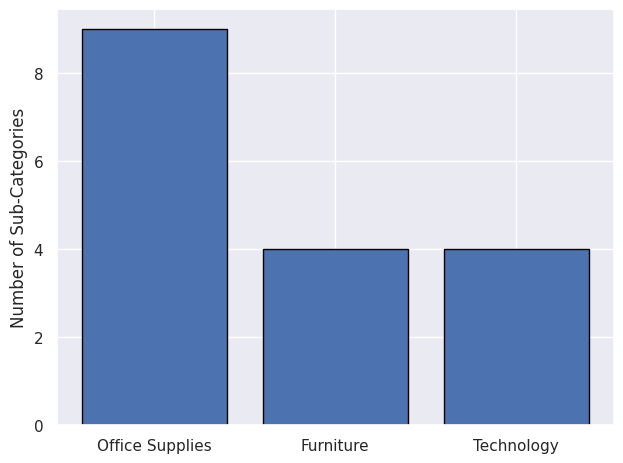

In [31]:
# Bar chart for sub-category counts
plt.bar(subcategory_count['Category'], subcategory_count['Sub-Category'], edgecolor='black')

# Axis label
plt.ylabel("Number of Sub-Categories")

# Layout adjustment
plt.tight_layout()

# Render plot
plt.show()

## Key Findings (by Category)

- **Office Supplies** has the highest number of unique sub‑categories at **9**, making it the most diverse category.
- **Furniture** and **Technology** each contain **4** unique sub‑categories, less than half of Office Supplies.

## Insights

- The wide variety within **Office Supplies** suggests a broad product assortment and potentially more granular customer needs within this category.
- The smaller number of sub‑categories in **Furniture** and **Technology** indicates more focused product ranges, which may simplify inventory and sales strategies.
- The imbalance in sub‑category distribution highlights opportunities to **expand product diversity** in Furniture and Technology or **streamline** the extensive Office Supplies category depending on business goals.

In [32]:
# Total sales by category and sub-category
subcategory_count_sales = df.groupby(['Category', 'Sub-Category'])['Sales'] \
    .sum().reset_index(name='total_sales') \
    .sort_values('total_sales', ascending=False)

# Display result
subcategory_count_sales.head()

,Category,Sub-Category,total_sales
16,Technology,Phones,"330,007.05"
1,Furniture,Chairs,"328,449.10"
11,Office Supplies,Storage,"223,843.61"
3,Furniture,Tables,"206,965.53"
6,Office Supplies,Binders,"203,412.73"


In [33]:
# Total sales by category
product_category = df.groupby('Category')['Sales'].sum().reset_index(name='total_sales') \
    .sort_values('total_sales', ascending=False)

# Top categories by sales
product_category.head()

,Category,total_sales
2,Technology,"836,154.03"
0,Furniture,"741,999.80"
1,Office Supplies,"719,047.03"


### **Which Product Categories Generate the Most Revenue?**

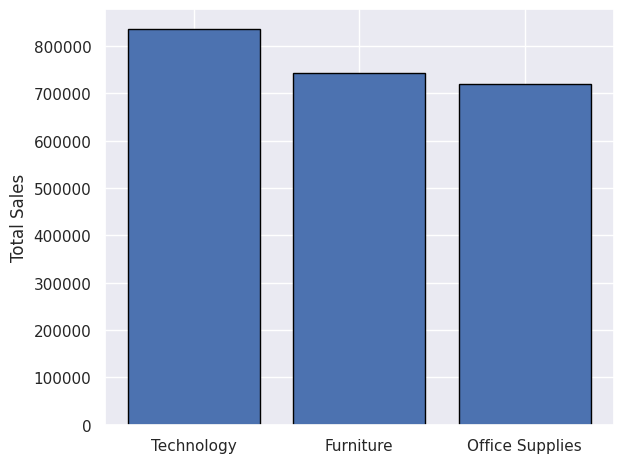

In [34]:
# Bar chart for category-wise sales
plt.bar(product_category['Category'], product_category['total_sales'], edgecolor='black')

# Axis label
plt.ylabel("Total Sales")

# Layout adjustment
plt.tight_layout()

# Render plot
plt.show()

## Key Findings (by Product Category)

- **Technology** leads all categories with the highest total sales, exceeding **800,000**.
- **Furniture** follows with strong performance, generating around **740,000** in total sales.
- **Office Supplies** ranks third, contributing approximately **720,000** in sales.

## Insights

- Technology stands out as the **top‑earning category**, indicating strong customer demand and a high‑value product mix.
- The relatively close sales figures for Furniture and Office Supplies suggest **balanced performance**, with both categories contributing significantly to overall revenue.
- The narrow gap between the mid‑tier categories highlights opportunities to **optimize pricing, promotions, or product assortment** to further boost their sales.
- The strong performance across all three categories indicates a **well‑diversified revenue base**, reducing dependency on any single category.

([<matplotlib.patches.Wedge at 0x7e1dfbdfc4d0>,
 [Text(0.4558501937655543, 1.001099695756575, 'Technology'),
  Text(-1.0859232694701606, -0.17541565729215064, 'Furniture'),
  Text(0.6096608927243867, -0.9155946678975931, 'Office Supplies')],
 [Text(0.24864556023575687, 0.5460543795035863, '36.4%'),
  Text(-0.5923217833473602, -0.09568126761390033, '32.3%'),
  Text(0.3325423051223927, -0.49941527339868713, '31.3%')])

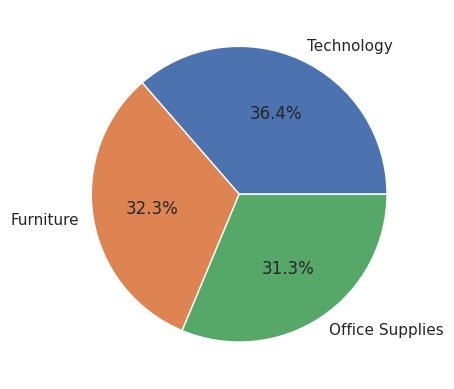

In [35]:
# Sales share by category
plt.pie(product_category['total_sales'], labels=product_category['Category'], autopct='%1.1f%%')

### **Which Sub-Categories Generate the Most Revenue?**

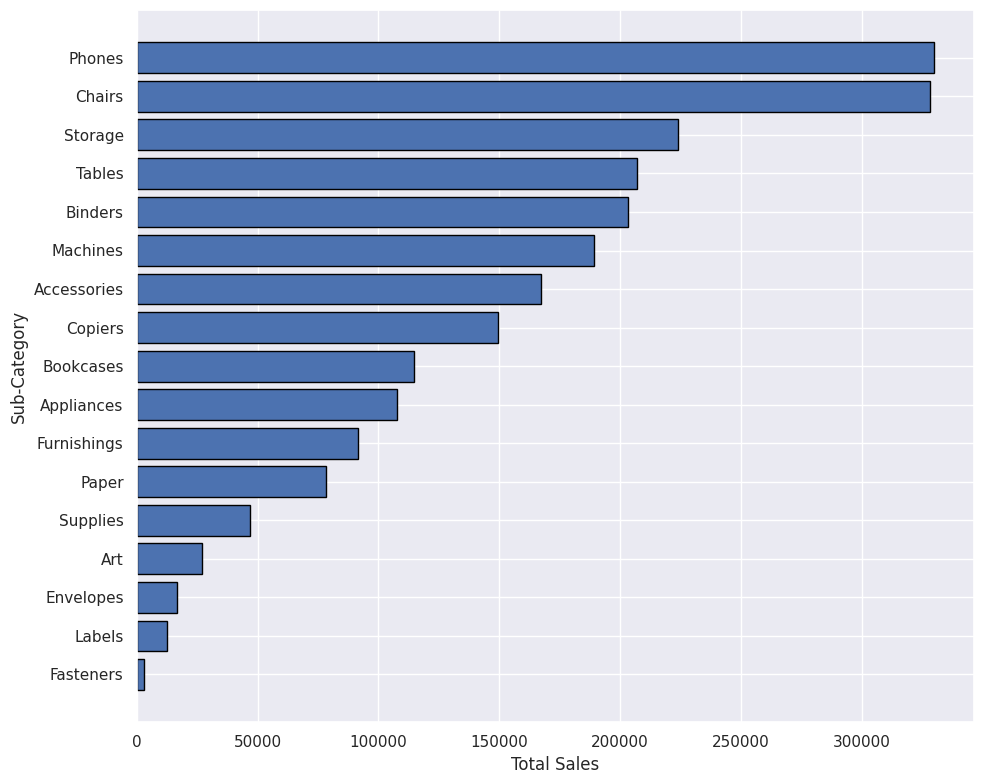

In [36]:
# Sort sub-categories by total sales (ascending)
plt.figure(figsize=(10, 8))
subcategory_count_sales = subcategory_count_sales.sort_values('total_sales', ascending=True)

# Horizontal bar chart of sub-category sales
plt.barh(subcategory_count_sales['Sub-Category'], subcategory_count_sales['total_sales'], edgecolor='black')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

## Key Findings (by Sub‑Category)

- **Phones** and **Chairs** generate the highest total sales, each exceeding **$300,000**, making them the strongest sub‑categories.
- **Storage**, **Tables**, **Binders**, and **Machines** form the next tier with moderate sales levels.
- **Fasteners** contribute the least, with sales close to **zero**, marking the lowest‑performing sub‑category.

## Insights

- The dominance of **Phones** and **Chairs** suggests these are core revenue drivers and should remain priority product lines.
- Mid‑tier sub‑categories show consistent performance, indicating stable demand but also room for targeted growth strategies.
- The extremely low sales for **Fasteners** highlight a potential issue-either low demand, limited assortment, or lack of visibility.
- The wide spread between top and bottom performers suggests opportunities to **rebalance inventory**, **optimize pricing**, or **reassess product relevance** across sub‑categories.

In [37]:
# Convert order date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract year from order date
df['Order Date Yearly'] = df['Order Date'].dt.year

# Aggregate sales by year
yearly_sales = df.groupby('Order Date Yearly')['Sales'].sum().reset_index()

# Rename columns for clarity
yearly_sales = yearly_sales.rename(columns={'Order Date Yearly': 'Year', 'Sales': 'Total Sales'})

# Display result
yearly_sales

,Year,Total Sales
0,2014,"484,247.50"
1,2015,"470,532.51"
2,2016,"609,205.60"
3,2017,"733,215.26"


### **How Have Sales Changed Over Time?**

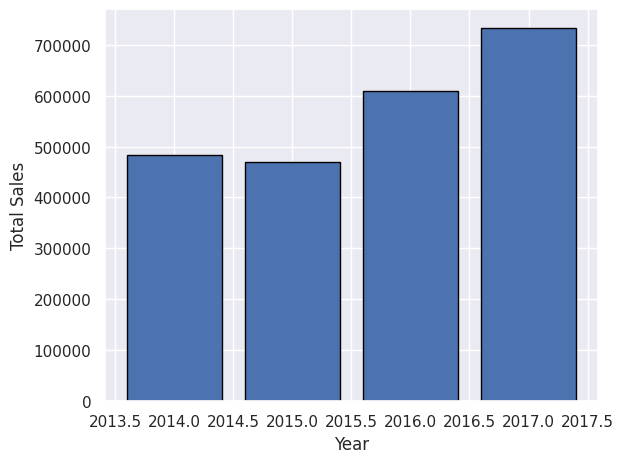

In [38]:
# Yearly sales trend (bar chart)
plt.bar(yearly_sales['Year'], yearly_sales['Total Sales'], edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

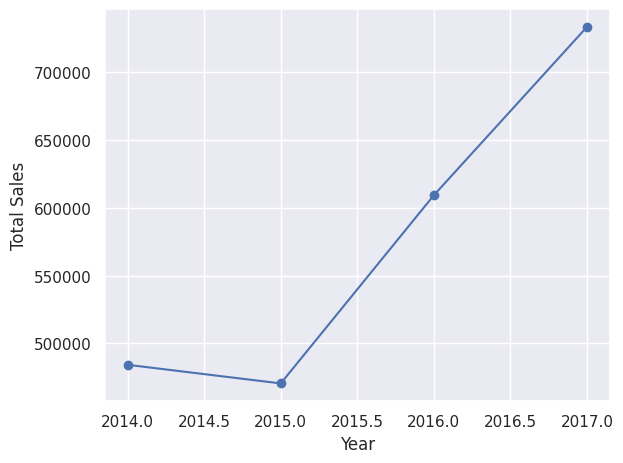

In [39]:
# Better chart - Line
# Yearly sales trend visualization
plt.plot(yearly_sales['Year'], yearly_sales['Total Sales'], marker='o', linestyle='solid')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

## Key Findings (Yearly Sales Trend)

- Total sales show a **consistent upward trend** across the four years displayed.
- Sales increase from roughly **480,000** in the first year to over **700,000** in the final year.
- Each year records a **higher total** than the previous one, with no declines.

## Insights

- The steady year‑over‑year growth indicates **strong business momentum** and effective sales strategies.
- The significant jump in the final year suggests improved market penetration, product performance, or operational efficiency.
- This upward trajectory can support **forecasting confidence**, helping justify future investments in scaling operations.
- Maintaining this growth pattern may require continued focus on **high‑performing segments, customer retention, and expansion opportunities**.

In [40]:
# Filter data for 2017 only
year_sales = df[df['Order Date'].dt.year == 2017]

# Aggregate sales by quarter
quarterly_sales = (
    year_sales
    .resample('QE', on='Order Date')['Sales']
    .sum()
    .reset_index()
    .rename(columns={
        'Order Date': 'Quarter',
        'Sales': 'Total Sales'
    })
)

# Display quarterly sales
print(quarterly_sales)

     Quarter  Total Sales
0 2017-03-31   123,144.86
1 2017-06-30   133,764.37
2 2017-09-30   196,251.96
3 2017-12-31   280,054.07


### **Quarterly Revenue Breakdown for 2017 (Focusing on 2017 as an example)**

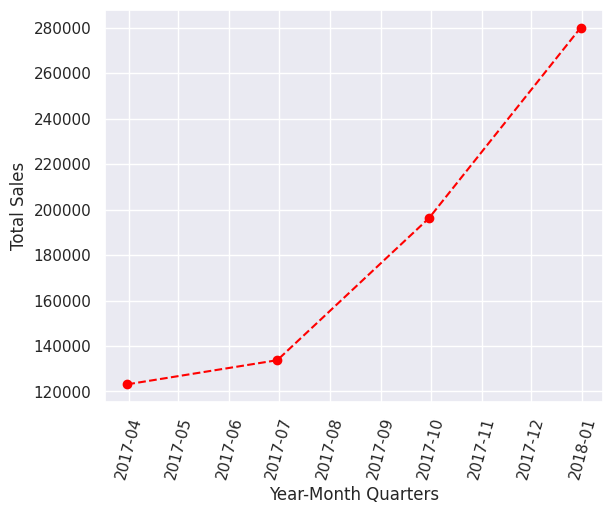

In [41]:
# Quarterly sales trend visualization (2017)
plt.plot(quarterly_sales['Quarter'], quarterly_sales['Total Sales'], marker='o', linestyle='--', color='red')

plt.xlabel('Year-Month Quarters')
plt.ylabel('Total Sales')

# Layout adjustment
plt.tight_layout()

# Rotate x-axis labels for readability
plt.xticks(rotation=75)

# Render plot
plt.show()

## Key Findings (Quarterly Sales - 2017)

- Quarterly sales show a **steady upward climb** throughout 2017.
- Each quarter records a **higher total sales value** than the previous one.
- The final quarter reaches the **highest sales level**, crossing well above earlier quarters.

## Insights

- The consistent quarter‑over‑quarter growth signals **strong market momentum** and effective sales execution during 2017.
- The sharp rise toward the end of the year may reflect **seasonal demand**, successful promotions, or improved operational efficiency.
- This pattern suggests a healthy trajectory that can support **confident forecasting** and strategic planning for subsequent years.
- Maintaining this growth may require continued focus on **high‑performing product lines, customer engagement, and targeted campaigns**.


In [42]:
# Filter data for 2017 only
yearly_sales = df[df['Order Date'].dt.year == 2017]

# Aggregate monthly sales using time resampling
monthly_sales = yearly_sales.resample('M', on='Order Date')['Sales'].sum()

# Convert to DataFrame
monthly_sales = monthly_sales.reset_index()

# Rename columns for clarity
monthly_sales = monthly_sales.rename(columns={'Order Date': 'Month', 'Sales': 'Total Monthly Sales'})

# Display monthly sales
monthly_sales.head()

,Month,Total Monthly Sales
0,2017-01-31,"43,971.37"
1,2017-02-28,"20,301.13"
2,2017-03-31,"58,872.35"
3,2017-04-30,"36,521.54"
4,2017-05-31,"44,261.11"


### **Sales Breakdown by Month (2017)**

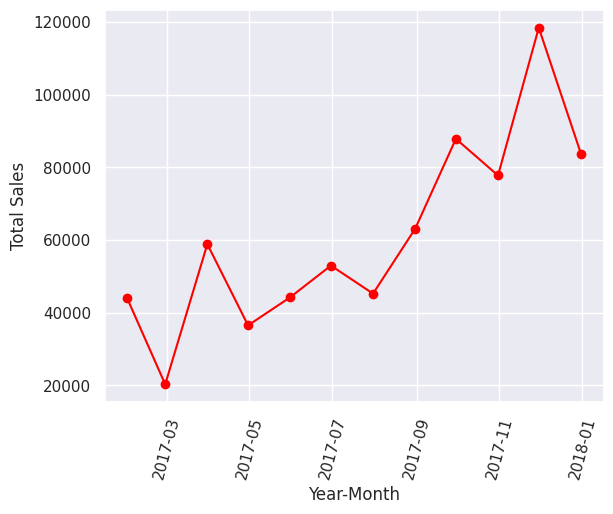

In [43]:
# Monthly sales trend visualization (2017)
plt.plot(monthly_sales['Month'], monthly_sales['Total Monthly Sales'], marker='o', linestyle='solid', color='red')

plt.xlabel('Year-Month')
plt.ylabel('Total Sales')

# Layout adjustment
plt.tight_layout()

# Rotate x-axis labels for readability
plt.xticks(rotation=75)

# Render plot
plt.show()

## Key Findings (Monthly Sales - 2017)

- Monthly sales show **significant fluctuations** throughout 2017, with several peaks and dips.
- Despite the variability, the overall pattern trends **upward**, ending the year at a much higher sales level than it began.
- The lowest months fall near **20,000–40,000**, while the strongest months approach **120,000**, indicating a wide performance range.

## Insights

- The month‑to‑month volatility suggests **seasonal effects, promotional cycles, or shifting customer demand** influencing sales.
- The strong upward movement toward the end of the year signals **growing momentum**, possibly driven by holiday demand or successful campaigns.
- Understanding the causes behind the peaks can help replicate high‑performing months, while analysing the troughs can guide **risk mitigation and stability planning**.
- The overall upward trajectory reinforces a positive long‑term trend, supporting **strategic investment and forecasting confidence**.


---

## **Dataset 2: Exploration Data Analysis**

In [44]:
# Load dataset
df = pd.read_excel("online_retail.xlsx", sheet_name=0)

# Preview data
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,"13,085.00",United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,"13,085.00",United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,"13,085.00",United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,"13,085.00",United Kingdom


In [45]:
# Check data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [46]:
# Checking data types of each features
# df.dtypes

In [47]:
# Descriptive statistics
df.describe()

# Quick overview of key statistics such as count, mean, standard deviation, min, max, and quartiles

,Quantity,InvoiceDate,Price,Customer ID
count,"525,461.00",525461,"525,461.00","417,534.00"
mean,10.34,2010-06-28 11:37:36.845017856,4.69,"15,360.65"
min,"-9,600.00",2009-12-01 07:45:00,"-53,594.36","12,346.00"
25%,1.00,2010-03-21 12:20:00,1.25,"13,983.00"
50%,3.00,2010-07-06 09:51:00,2.10,"15,311.00"
75%,10.00,2010-10-15 12:45:00,4.21,"16,799.00"
max,"19,152.00",2010-12-09 20:01:00,"25,111.09","18,287.00"
std,107.42,NaN,146.13,"1,680.81"


In [48]:
# Categorical summary
df.describe(include='O').T

,count,unique,top,freq
Invoice,525461,28816,537434,675
StockCode,525461,4632,85123A,3516
Description,522533,4681,WHITE HANGING HEART T-LIGHT HOLDER,3549
Country,525461,40,United Kingdom,485852


In [49]:
# Check missing values
df.isnull().sum()

# or

# df.isna().sum()
# df.isna().mean()*100

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [50]:
# Missing Customer IDs
df[df["Customer ID"].isna()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [51]:
# Check negative quantities
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia


In [52]:
# Check negative quantities count
print(len(df[df["Quantity"] < 0]))

12326


### **Detecting Invalid Invoice IDs**

In [53]:
# Check invoices not matching 6-digit format
df["Invoice"] = df["Invoice"].astype("str")
df[df["Invoice"].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,"12,605.00",Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,"15,329.00",United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,"15,329.00",United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,"15,329.00",United Kingdom


### **Detecting Non-Numeric Characters in Invoice IDs**

In [54]:
# Check Invoice non-digit characters
df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [55]:
# Check invoices starting with 'A'
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.36",NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.79",NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.87",NaN,United Kingdom


### **Detecting Invalid StockCode Formats**

In [56]:
# Check invalid StockCode format
df["StockCode"] = df["StockCode"].astype("str")
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [57]:
# Check StockCode starting with 'DOT'
df[df["StockCode"].str.contains("^DOT")].head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom


## **Data Cleaning**

In [58]:
# Create working copy
cleaned_df = df.copy()

### **Retaining Only Valid Invoice Numbers**

In [59]:
# Keep valid invoices only
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")

mask = cleaned_df["Invoice"].str.match("^\\d{6}$") == True

cleaned_df = cleaned_df[mask]

cleaned_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


### **Retaining Only Valid Product Codes**

In [60]:
# Keep valid StockCode values
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype("str")

mask = (
    cleaned_df["StockCode"].str.match("^\\d{5}$") |
    cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") |
    cleaned_df["StockCode"].str.match("^PADS$")
)

cleaned_df = cleaned_df[mask]

cleaned_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [61]:
# Drop missing Customer IDs (not required for current steps)
cleaned_df.dropna(subset=["Customer ID"], inplace=True)

In [62]:
# Summary statistics
cleaned_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,"406,337.00",13.62,1.00,2.00,5.00,12.00,"19,152.00",97.00
InvoiceDate,406337,2010-07-01 10:11:06.543288320,2009-12-01 07:45:00,2010-03-26 14:01:00,2010-07-09 15:48:00,2010-10-14 17:09:00,2010-12-09 20:01:00,NaN
Price,"406,337.00",2.99,0.00,1.25,1.95,3.75,295.00,4.29
Customer ID,"406,337.00","15,373.63","12,346.00","14,004.00","15,326.00","16,814.00","18,287.00","1,677.37"


In [63]:
# Check zero-price records
len(cleaned_df[cleaned_df["Price"] == 0])

28

In [64]:
# Remove zero-price records
cleaned_df = cleaned_df[cleaned_df["Price"] > 0.0]

In [65]:
# Check minimum price
cleaned_df["Price"].min()

0.001

In [66]:
# Retention rate after cleaning
len(cleaned_df) / len(df)

0.7732429238325965

> **Dropped about **23%*** of records during cleaning.*

## **Feature Engineering**

### **Deriving Revenue for Each Order Line**

In [67]:
# Create sales value column by doing the product of quantity and price
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]

# Alternative row-wise method using apply
# cleaned_df["SalesLineTotal"] = cleaned_df.apply(lambda x: x["Quantity"] * x["Price"],axis=1)

# View updated dataset
cleaned_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00


### **Customer Purchase Behavior Summary (RFM)**

In [68]:
# Aggregate customer-level metrics (RFM base)
aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
    .agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )

# Preview aggregated results
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,"12,346.00",169.36,2,2010-06-28 13:53:00
1,"12,347.00","1,323.32",2,2010-12-07 14:57:00
2,"12,348.00",221.16,1,2010-09-27 14:59:00
3,"12,349.00","2,221.14",2,2010-10-28 08:23:00
4,"12,351.00",300.93,1,2010-11-29 15:23:00


### **Customer Recency Analysis**

In [69]:
# Compute reference date for recency
max_invoice_date = aggregated_df["LastInvoiceDate"].max()

# Calculate recency in days (RFM feature)
aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days

# Preview results
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,"12,346.00",169.36,2,2010-06-28 13:53:00,164
1,"12,347.00","1,323.32",2,2010-12-07 14:57:00,2
2,"12,348.00",221.16,1,2010-09-27 14:59:00,73
3,"12,349.00","2,221.14",2,2010-10-28 08:23:00,42
4,"12,351.00",300.93,1,2010-11-29 15:23:00,10


### **Distribution of RFM Metrics**

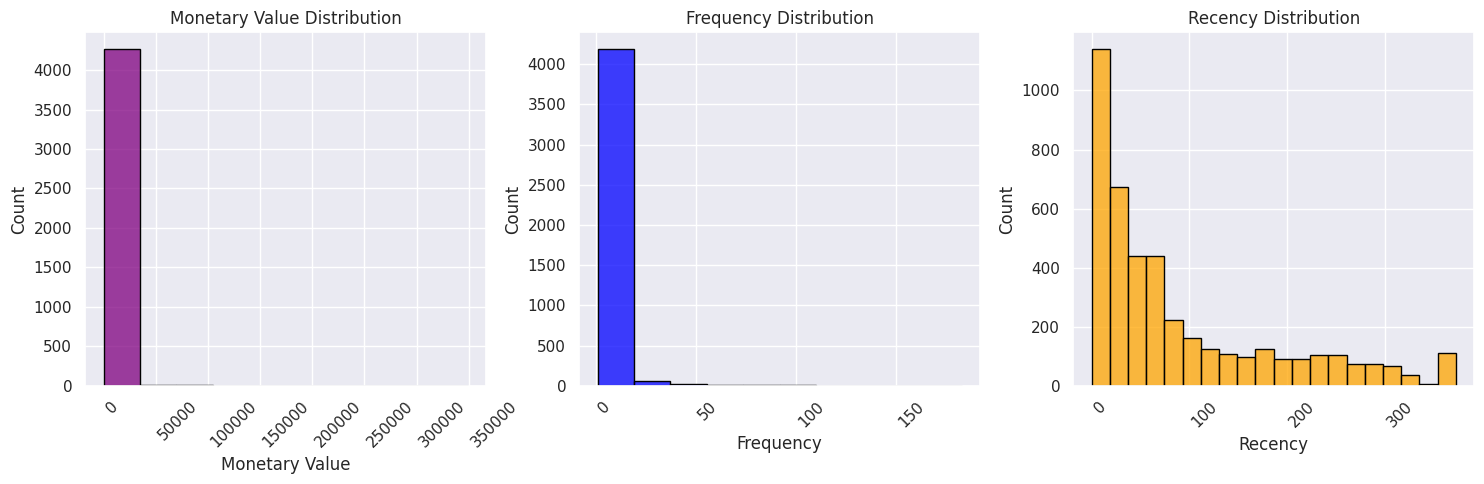

In [70]:
# Plot RFM distributions
plt.figure(figsize=(15, 5))

# Monetary Value
plt.subplot(1, 3, 1)
sns.histplot(aggregated_df['MonetaryValue'], bins=10, color='purple', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.xticks(rotation=45, ha='left')
plt.ylabel('Count')

# Frequency
plt.subplot(1, 3, 2)
sns.histplot(aggregated_df['Frequency'], bins=10, color='blue', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.xticks(rotation=45, ha='left')
plt.ylabel('Count')

# Recency
plt.subplot(1, 3, 3)
sns.histplot(aggregated_df['Recency'], bins=20, color='orange', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.xticks(rotation=45, ha='left')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Key Findings (RFM Distributions)

- **Monetary Value** is heavily concentrated near the lower end, with the majority of customers generating **very small total spend**, and only a small number contributing high monetary values.
- **Frequency** shows a similar pattern, where most customers make **very few purchases**, and only a small minority purchase frequently.
- **Recency** displays a **right‑skewed distribution**, with many customers having **recent activity**, and progressively fewer customers showing long gaps since their last purchase.

## Insights

- The strong left‑skew in **Monetary Value** and **Frequency** suggests a classic **long‑tail customer base**, where a small group of high‑value customers drives a disproportionate share of revenue.
- The high concentration of customers with **recent purchases** indicates strong current engagement, which is favourable for retention and upsell strategies.
- Customers with **low frequency but recent activity** may be ideal targets for nurturing into higher‑value segments.
- The distributions highlight the importance of **customer segmentation**, as different groups (high‑value, high‑frequency, long‑recency, etc.) will require tailored marketing and retention approaches.

### **RFM Outlier Analysis**

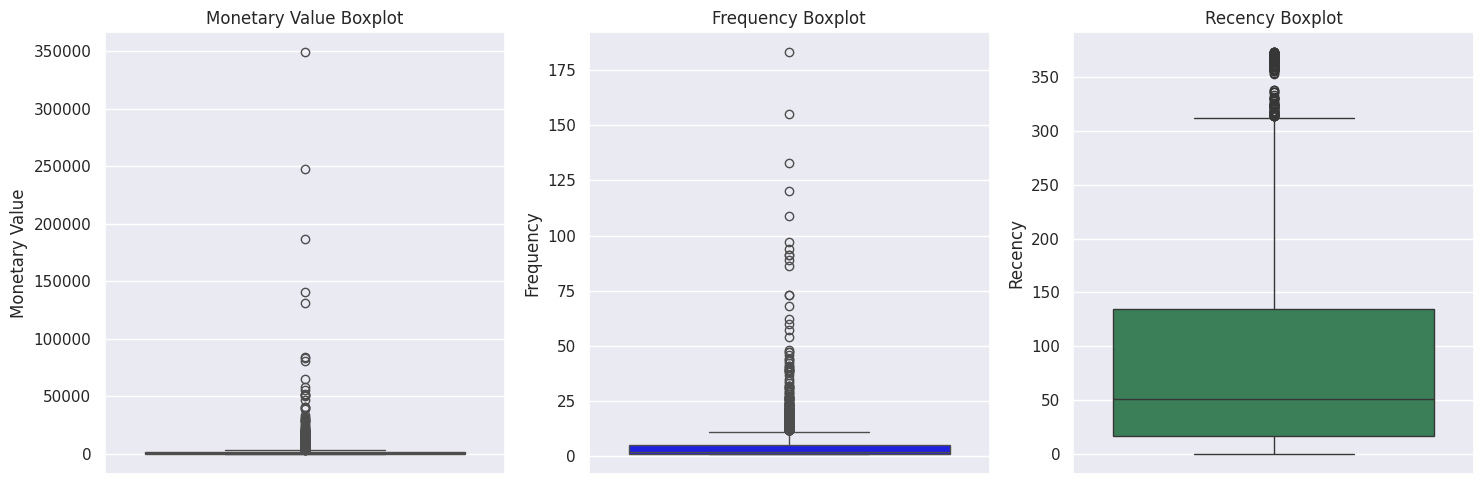

In [71]:
# Plot RFM boxplots
plt.figure(figsize=(15, 5))

# Monetary Value
plt.subplot(1, 3, 1)
sns.boxplot(y=aggregated_df['MonetaryValue'], color='orange')
plt.title('Monetary Value Boxplot')
plt.ylabel('Monetary Value')

# Frequency
plt.subplot(1, 3, 2)
sns.boxplot(y=aggregated_df['Frequency'], color='blue')
plt.title('Frequency Boxplot')
plt.ylabel('Frequency')

# Recency
plt.subplot(1, 3, 3)
sns.boxplot(y=aggregated_df['Recency'], color='seagreen')
plt.title('Recency Boxplot')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

## Key Findings

- All three RFM metrics: **Monetary Value**, **Frequency**, and **Recency** - show **many outliers** far beyond the typical range.
- The core distributions are tightly clustered, with extreme values stretching the scales.

## Insights

- The large number of outliers indicates **highly uneven customer behaviour** that could distort analysis.
- These outliers should be **reviewed and potentially treated** depending on the modelling or segmentation goals.

In [72]:
# Detect MonetaryValue outliers using IQR method
M_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1

# Filter outlier customers
monetary_outliers_df = aggregated_df[
    (aggregated_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR)) |
    (aggregated_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))
].copy()

# Summary of outliers
monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.00,423.00,423.00,423,423.00
mean,"15,103.04","12,188.10",17.17,2010-11-09 12:26:02.978723328,30.04
min,"12,357.00","3,802.04",1.00,2009-12-10 18:03:00,0.00
25%,"13,622.00","4,605.94",8.00,2010-11-08 13:17:30,3.00
50%,"14,961.00","6,191.32",12.00,2010-11-26 12:19:00,13.00
75%,"16,692.00","10,273.24",18.00,2010-12-06 10:34:30,31.00
max,"18,260.00","349,164.35",183.00,2010-12-09 19:32:00,364.00
std,"1,728.66","25,830.85",19.73,NaN,51.54


In [73]:
# Detect Frequency outliers using IQR method
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1

# Filter outlier customers
frequency_outliers_df = aggregated_df[
    (aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) |
    (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))
].copy()

# Summary of outliers
frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,"15,352.66","14,409.71",23.81,2010-11-23 11:06:20.645161216,16.09
min,"12,437.00","1,094.39",12.00,2010-05-12 16:51:00,0.00
25%,"13,800.00","4,331.56",13.00,2010-11-20 13:14:30,2.00
50%,"15,465.00","6,615.77",17.00,2010-12-02 10:46:00,7.00
75%,"16,828.50","11,692.41",23.00,2010-12-07 11:08:30,19.00
max,"18,260.00","349,164.35",183.00,2010-12-09 19:32:00,211.00
std,"1,748.43","31,381.74",21.93,NaN,26.59


In [74]:
# Remove outliers from both Monetary and Frequency
non_outliers_df = aggregated_df[
    (~aggregated_df.index.isin(monetary_outliers_df.index)) &
    (~aggregated_df.index.isin(frequency_outliers_df.index))
]

# Summary of cleaned dataset
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,"3,809.00","3,809.00","3,809.00",3809,"3,809.00"
mean,"15,376.48",885.50,2.86,2010-09-03 11:16:46.516146176,97.08
min,"12,346.00",1.55,1.00,2009-12-01 10:49:00,0.00
25%,"13,912.00",279.91,1.00,2010-07-08 14:48:00,22.00
50%,"15,389.00",588.05,2.00,2010-10-12 16:25:00,58.00
75%,"16,854.00","1,269.05",4.00,2010-11-17 13:14:00,154.00
max,"18,287.00","3,788.21",11.00,2010-12-09 20:01:00,373.00
std,"1,693.20",817.67,2.24,NaN,98.11


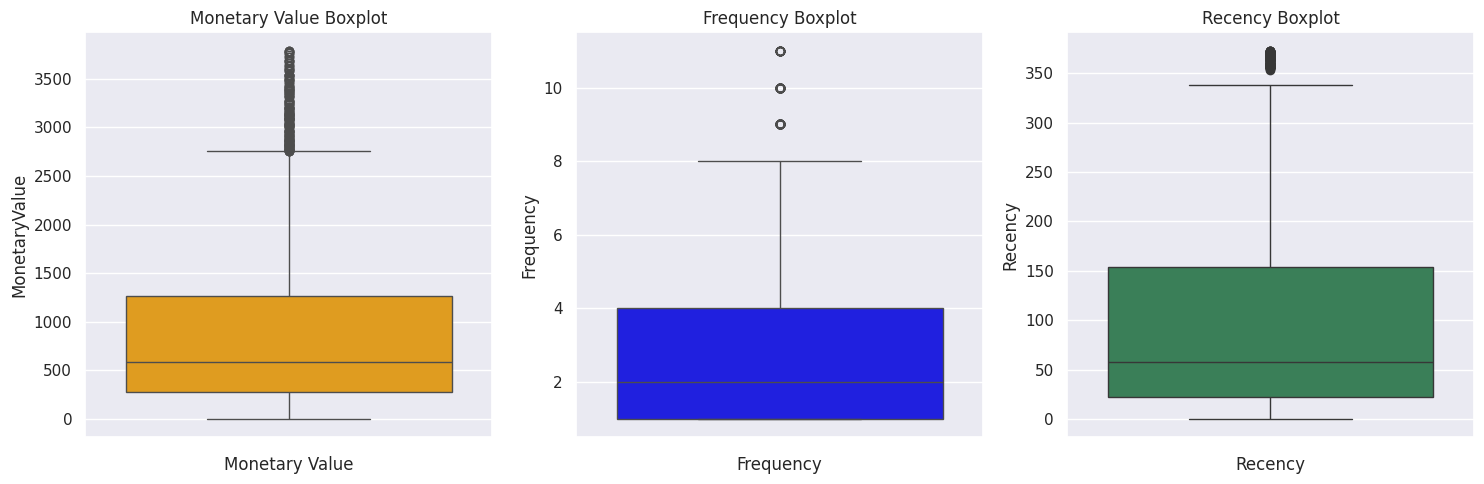

In [75]:
# Boxplots after removing outliers
plt.figure(figsize=(15, 5))

# Monetary Value
plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='orange')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

# Frequency
plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='blue')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

# Recency
plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='seagreen')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

## Key Findings (Post-Outlier Removal)

- The **Monetary Value**, **Frequency**, and **Recency** boxplots now show **much tighter distributions**, with only a few mild outliers remaining.
- The central ranges for all three metrics are now **more stable and representative** of typical customer behaviour.

## Insights

- Removing extreme outliers has produced **cleaner, more reliable RFM distributions**, improving the quality of downstream analysis.
- The reduced spread makes it easier to **identify meaningful patterns** and supports more accurate segmentation or modelling.

### **Customer Distribution in RFM Space**

In [76]:
# Interactive 3D RFM scatter plot
fig = px.scatter_3d(
    non_outliers_df,
    x="MonetaryValue",
    y="Frequency",
    z="Recency",
    opacity=0.7
)

# Blue color
fig.update_traces(marker=dict(color="blue"))

# Chart axes
fig.update_layout(
    title="Scatter Plot of Customer Data",
    scene=dict(
        xaxis_title="Monetary Value",
        yaxis_title="Frequency",
        zaxis_title="Recency"
    )
)

fig.show()

Standard scaling transforms the features of the data to have a mean of 0 and a standard deviation of 1, ensuring that each feature contributes equally to the analysis.

$$
z = \frac{x - \mu}{\sigma}
$$

Where:
- $z$ is the standardized value,
- $x$ is the original value,
- $\mu$ is the mean of the feature,
- $\sigma$ is the standard deviation of the feature.

In [77]:
# Initialize standard scaler for normalization
scaler = StandardScaler()

# Scale RFM features to equalize magnitude
scaled_data = scaler.fit_transform(
    non_outliers_df[["MonetaryValue", "Frequency", "Recency"]]
)

# Output scaled array
scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]])

In [78]:
# Convert scaled array into DataFrame with original structure
scaled_data_df = pd.DataFrame(
    scaled_data,
    index=non_outliers_df.index,
    columns=("MonetaryValue", "Frequency", "Recency")
)

# View scaled dataset
scaled_data_df.head()

,MonetaryValue,Frequency,Recency
0,-0.88,-0.38,0.68
1,0.54,-0.38,-0.97
2,-0.81,-0.83,-0.25
3,1.63,-0.38,-0.56
4,-0.72,-0.83,-0.89


### **3D Visualization of RFM Metrics (Scaled)**

In [79]:
# Interactive 3D RFM scatter plot for scaled data
fig = px.scatter_3d(
    scaled_data_df,
    x="MonetaryValue",
    y="Frequency",
    z="Recency",
    opacity=0.7
)

# Blue color
fig.update_traces(marker=dict(color="blue"))

# Chart axes
fig.update_layout(
    title="Scatter Plot of Customer Data (Scaled)",
    scene=dict(
        xaxis_title="Monetary Value",
        yaxis_title="Frequency",
        zaxis_title="Recency"
    )
)

fig.show()

### **K-Means Cluster Evaluation**

> ##### Identifying the Best Customer Segmentation Structure (**best number of clusters**).

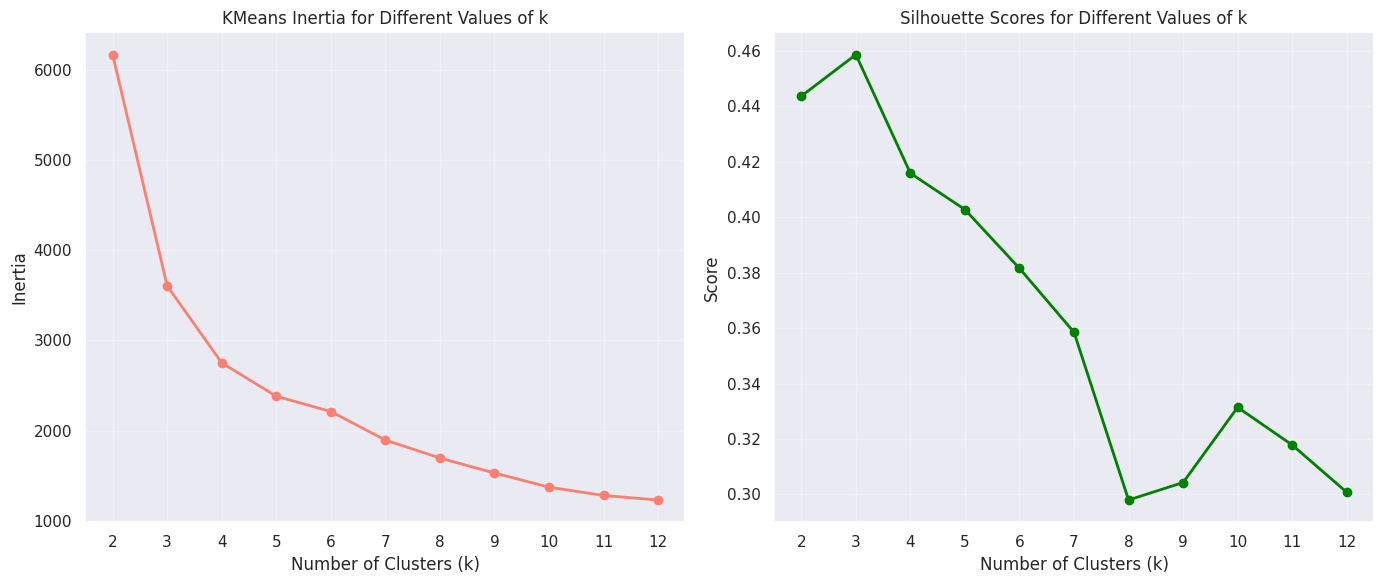

In [80]:
# K selection for KMeans (Elbow + Silhouette)
max_k = 12

inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

# Evaluate clustering performance across k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(scaled_data_df)

    silhouette_scores.append(silhouette_score(scaled_data_df, cluster_labels))
    inertia.append(kmeans.inertia_)

# Plot evaluation metrics
plt.figure(figsize=(14, 6))

# Elbow Chart
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o', linewidth=2, color='salmon')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(alpha=0.3)

# Silhouette Chart
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', linewidth=2, color='green')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation Summary

### Inertia (Elbow Method)
- Inertia decreases substantially up to **k = 4**, after which the rate of improvement slows.
- This suggests **diminishing returns** from adding more clusters beyond **k = 4**.

### Silhouette Score
- The silhouette score reaches its **highest value at k = 3**, indicating the strongest cluster separation.
- **k = 4** still achieves a relatively high silhouette score, while scores generally decline for larger values of **k**.

### Conclusion
The two evaluation metrics suggest slightly different optimal values:
- The **Elbow Method** indicates that **k = 4** is a reasonable choice due to the point of diminishing returns.
- The **Silhouette Score** favors **k = 3**, as it provides the highest cluster quality.

Overall, **k = 4** represents a good compromise between reducing inertia and maintaining strong cluster separation, making it a well-balanced and analytically justifiable choice for segmentation.

In [81]:
# Fit KMeans model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=1000)

# Assign cluster labels
cluster_labels = kmeans.fit_predict(scaled_data_df)

# Output cluster labels
cluster_labels

array([1, 0, 2, ..., 1, 0, 0], dtype=int32)

In [82]:
# Assign cluster labels to original dataset
non_outliers_df["Cluster"] = cluster_labels

# View clustered dataset
non_outliers_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,"12,346.00",169.36,2,2010-06-28 13:53:00,164,1
1,"12,347.00","1,323.32",2,2010-12-07 14:57:00,2,0
2,"12,348.00",221.16,1,2010-09-27 14:59:00,73,2
3,"12,349.00","2,221.14",2,2010-10-28 08:23:00,42,0
4,"12,351.00",300.93,1,2010-11-29 15:23:00,10,2


### **Customer Segmentation Using RFM Clusters**

In [83]:
# Cluster color mapping
cluster_colors = {
    0: "#636EFA",
    1: "#EF553B",
    2: "#98FF98",
    3: "#AB63FA"
}

# Map colors to clusters
colors = non_outliers_df['Cluster'].map(cluster_colors)

# Chart characteristics
fig = px.scatter_3d(
    non_outliers_df,
    x="MonetaryValue",
    y="Frequency",
    z="Recency",
    color="Cluster",
    color_discrete_map=cluster_colors,
    opacity=0.75
)

# Chart axes
fig.update_layout(
    title="Customer Clusters (RFM)",
    scene=dict(
        xaxis_title="Monetary Value",
        yaxis_title="Frequency",
        zaxis_title="Recency"
    )
)

fig.show()

## Key Insight

> The 3D RFM scatter plot shows **four clearly separated customer clusters**, confirming that the segmentation model has successfully grouped customers into distinct behavioural segments.

### **RFM Profile Comparison Across Customer Clusters**

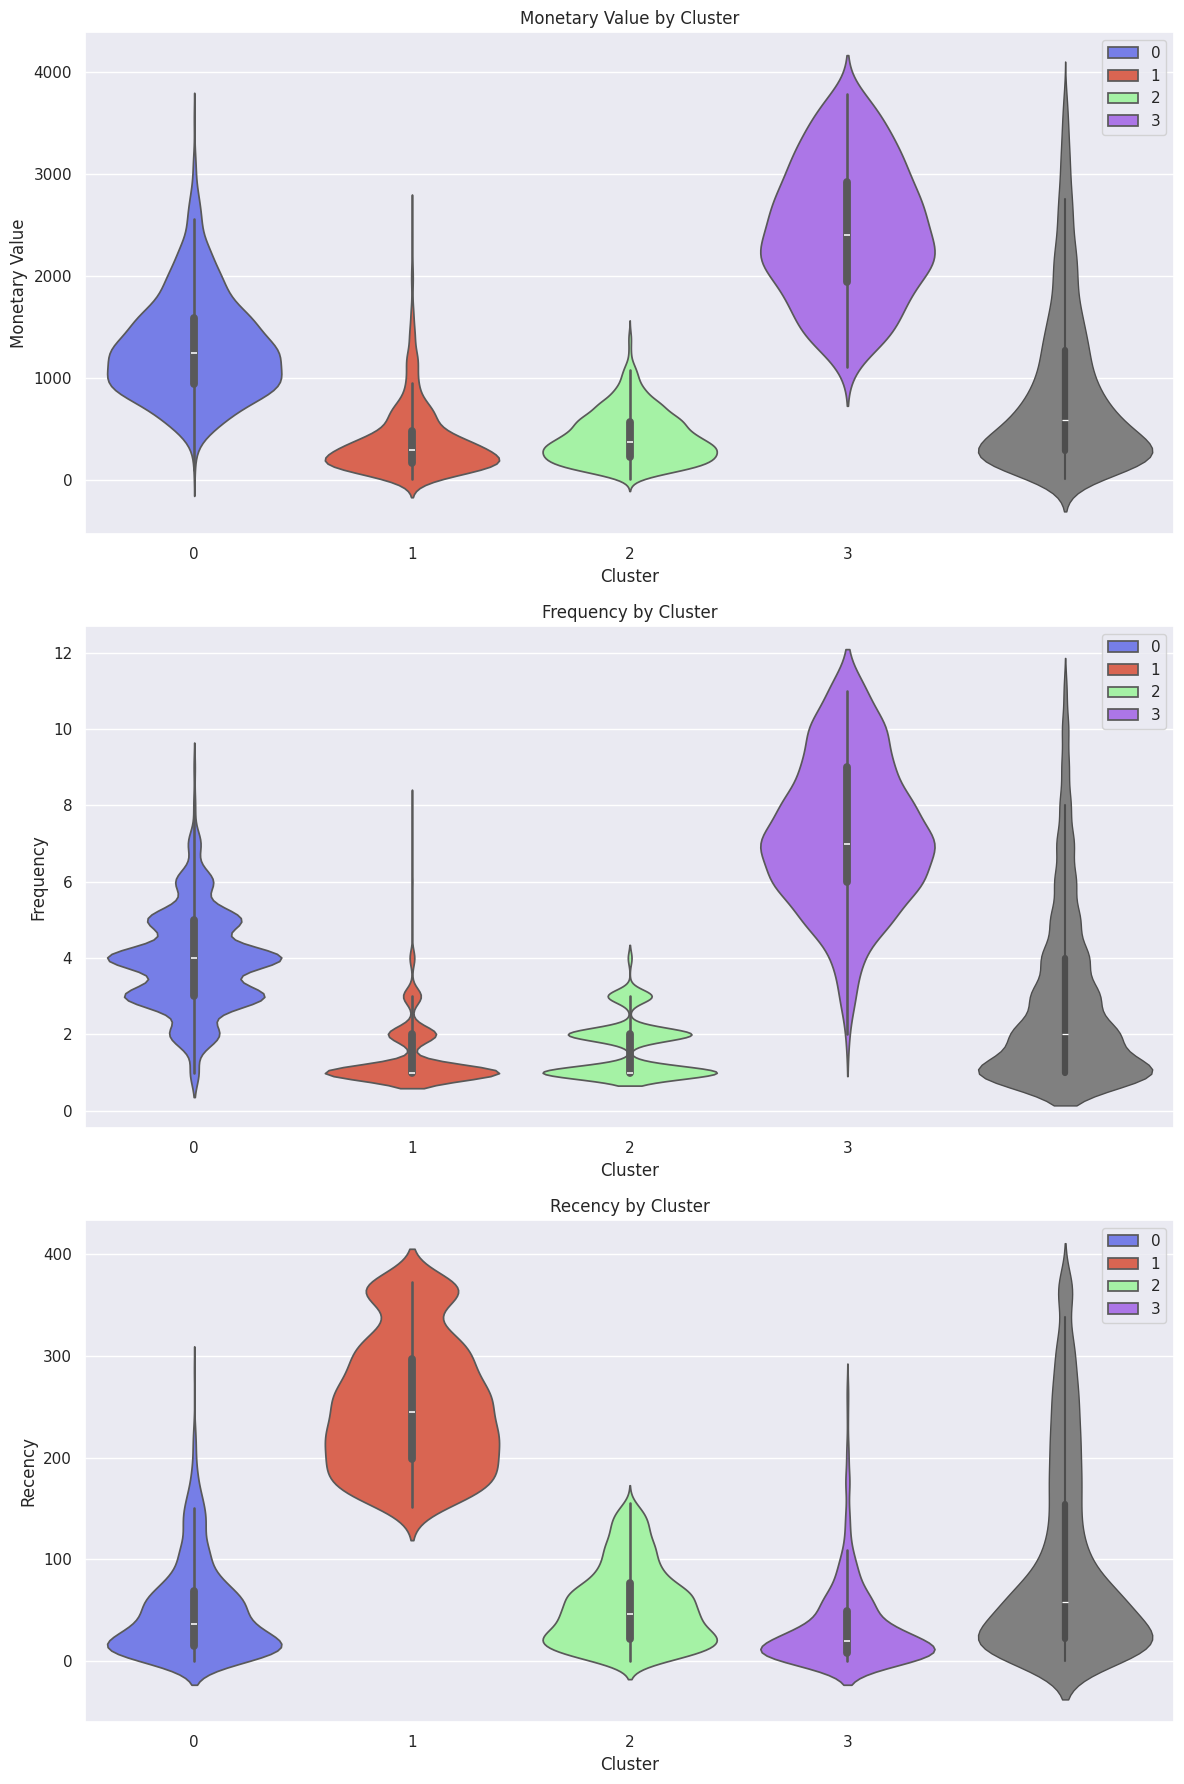

In [84]:
plt.figure(figsize=(12, 18))

# Monetary Value
plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

# Frequency
plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

# Recency
plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

1. **Cluster 0 (Blue): "Retain"**
* Rationale: This cluster represents high-value customers who purchase regularly, though not always very recently. The focus should be on retention efforts to maintain their loyalty and spending levels.
> Action: Implement loyalty programs, personalized offers, and regular engagement to ensure they remain active.

2. **Cluster 1 (Orange): "Re-Engage"**
* Rationale: This group includes lower-value, infrequent buyers who haven’t purchased recently. The focus should be on re-engagement to bring them back into active purchasing behavior.
> Action: Use targeted marketing campaigns, special discounts, or reminders to encourage them to return and purchase again.

3. **Cluster 2 (Green): "Nurture"**
* Rationale: This cluster represents the least active and lowest-value customers, but they have made recent purchases. These customers may be new or need nurturing to increase their engagement and spending.
> Action: Focus on building relationships, providing excellent customer service, and offering incentives to encourage more frequent purchases.

4. **Cluster 3 (Red): "Reward"**
* Rationale: This cluster includes high-value, very frequent buyers, many of whom are still actively purchasing. They are the most loyal customers, and rewarding their loyalty is key to maintaining their engagement.
> Action: Implement a robust loyalty program, provide exclusive offers, and recognize their loyalty to keep them engaged and satisfied.

**Summary of Cluster Names:**

* Cluster 0 (Blue): "Retain"
* Cluster 1 (Orange): "Re-Engage"
* Cluster 2 (Green): "Nurture"
* Cluster 3 (Red): "Reward"

In [85]:
# Find overlapping outlier indices
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

# Split outlier groups
monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

# Label outlier types
monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

# Combine all outliers
outlier_clusters_df = pd.concat([
    monetary_only_outliers,
    frequency_only_outliers,
    monetary_and_frequency_outliers
])

# View outlier dataset
outlier_clusters_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,"12,357.00","11,229.99",1,2010-11-16 10:05:00,23,-1
25,"12,380.00","4,782.84",4,2010-08-31 14:54:00,100,-1
42,"12,409.00","12,346.62",4,2010-10-15 10:24:00,55,-1
48,"12,415.00","19,468.84",4,2010-11-29 15:07:00,10,-1
61,"12,431.00","4,145.52",11,2010-12-01 10:03:00,8,-1


### **RFM Profile of Outlier Customer Clusters**

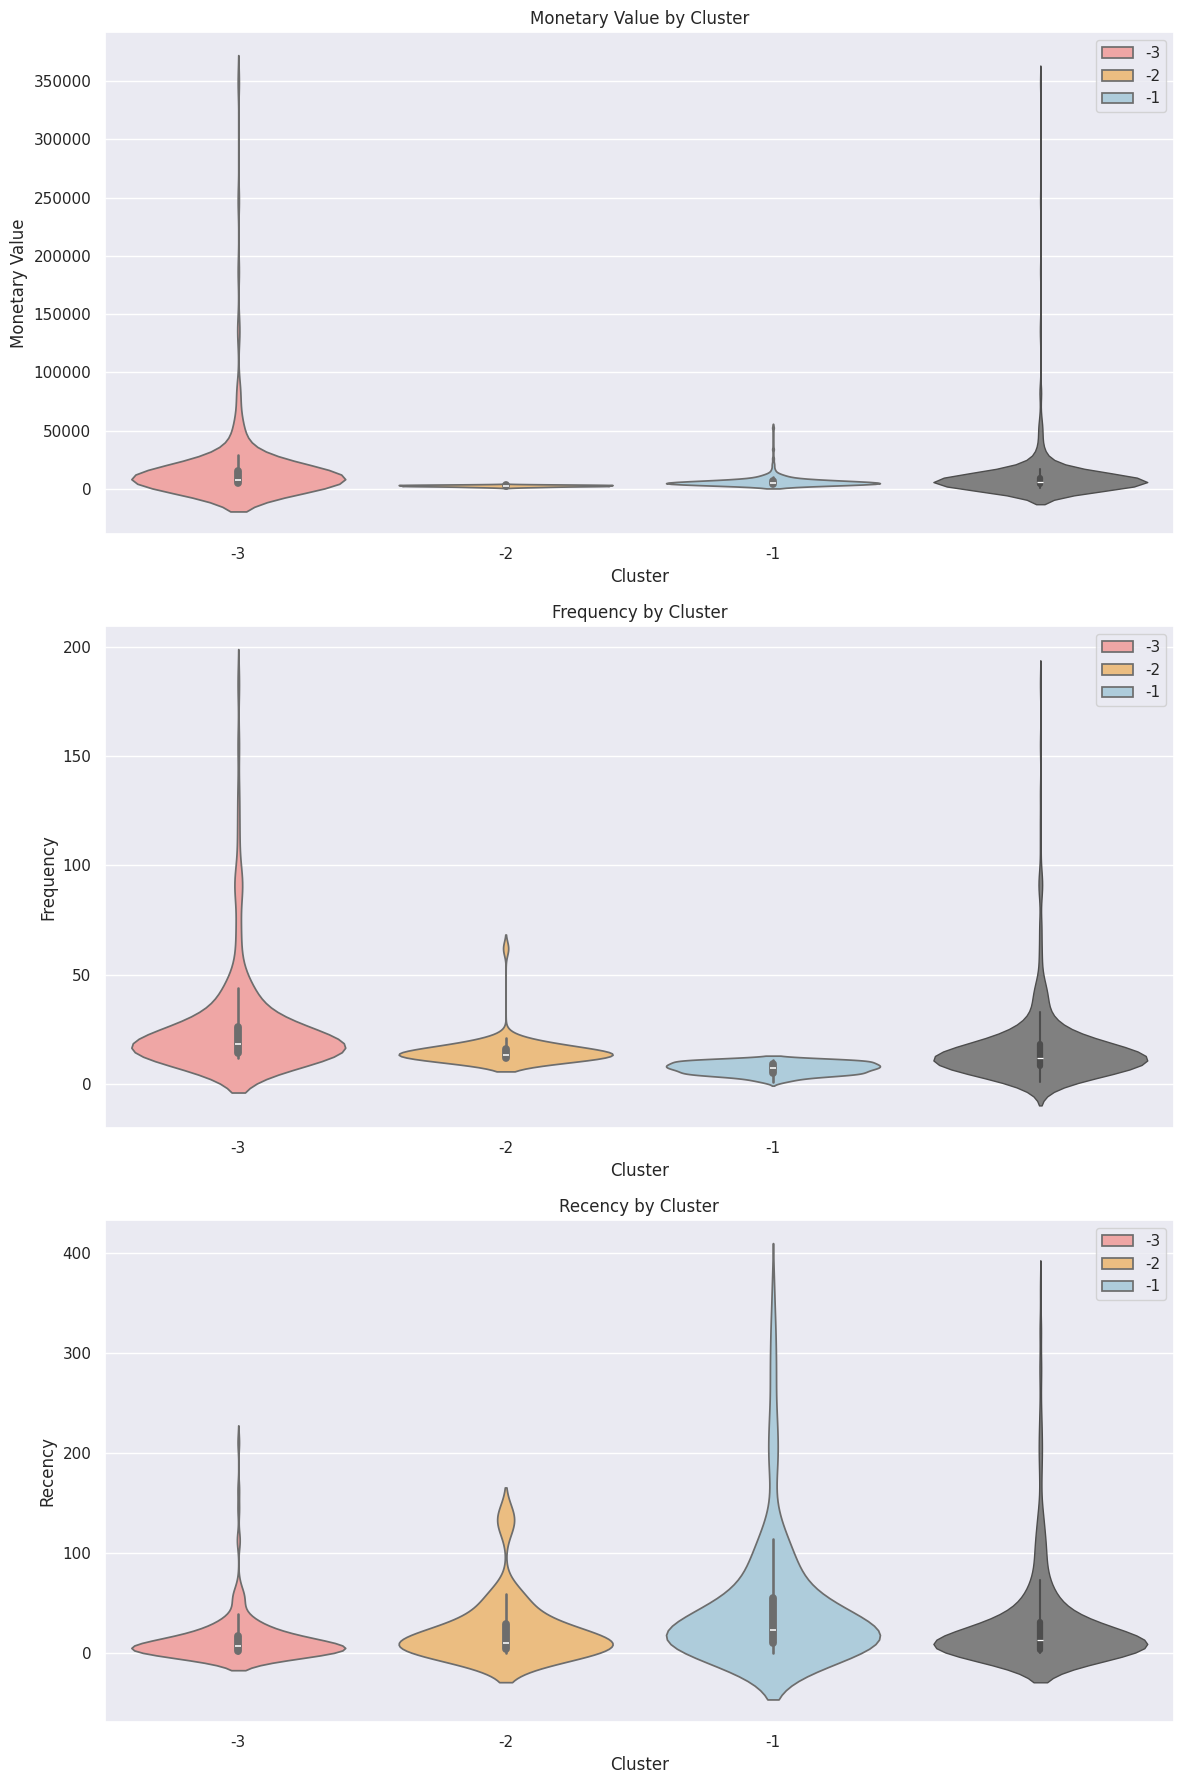

In [86]:
# Outlier cluster color mapping
cluster_colors = {
    -1: "#A6CEE3",
    -2: "#FDBF6F",
    -3: "#FB9A99"
}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
# Monetary distribution by outlier cluster
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
# Frequency distribution by outlier cluster
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
# Recency distribution by outlier cluster
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

* **Cluster -1 (Monetary Outliers) PAMPER:**
Characteristics: High spenders but not necessarily frequent buyers. Their purchases are large but infrequent.
> Potential Strategy: Focus on maintaining their loyalty with personalized offers or luxury services that cater to their high spending capacity.

* **Cluster -2 (Frequency Outliers) UPSELL:**
Characteristics: Frequent buyers who spend less per purchase. These customers are consistently engaged but might benefit from upselling opportunities.
> Potential Strategy: Implement loyalty programs or bundle deals to encourage higher spending per visit, given their frequent engagement.

* **Cluster -3 (Monetary & Frequency Outliers) DELIGHT:**
Characteristics: The most valuable outliers, with extreme spending and frequent purchases. They are likely the top-tier customers who require special attention.
> Potential Strategy: Develop VIP programs or exclusive offers to maintain their loyalty and encourage continued engagement.

### **Translating Clusters into Customer Segments**

In [87]:
# Maps each cluster ID to a clear, business customer segment label
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [88]:
# Display dataframe with clustering labels
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])
full_clustering_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,"12,346.00",169.36,2,2010-06-28 13:53:00,164,1
1,"12,347.00","1,323.32",2,2010-12-07 14:57:00,2,0
2,"12,348.00",221.16,1,2010-09-27 14:59:00,73,2
3,"12,349.00","2,221.14",2,2010-10-28 08:23:00,42,0
4,"12,351.00",300.93,1,2010-11-29 15:23:00,10,2


In [89]:
# Dataframe with cluster label names
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)
full_clustering_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,"12,346.00",169.36,2,2010-06-28 13:53:00,164,1,RE-ENGAGE
1,"12,347.00","1,323.32",2,2010-12-07 14:57:00,2,0,RETAIN
2,"12,348.00",221.16,1,2010-09-27 14:59:00,73,2,NURTURE
3,"12,349.00","2,221.14",2,2010-10-28 08:23:00,42,0,RETAIN
4,"12,351.00",300.93,1,2010-11-29 15:23:00,10,2,NURTURE


### **Understanding Customer Segments: Size and Value Comparison**

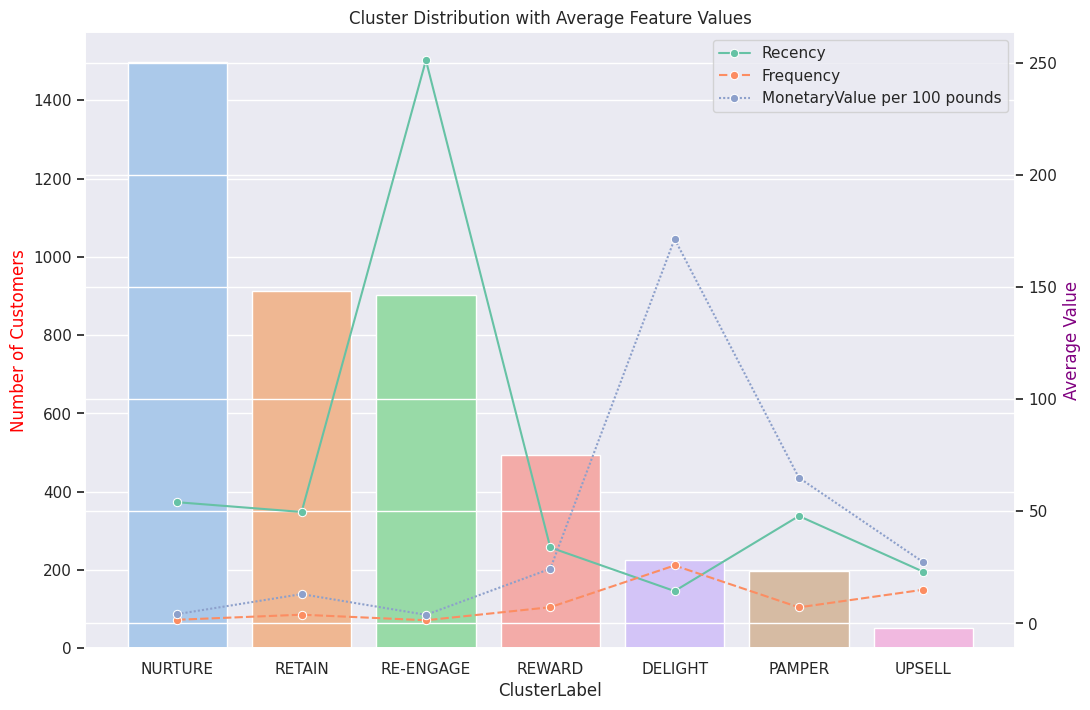

In [90]:
# Count customers per cluster
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()

# Scale monetary value for easier visual comparison
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00

# Compute average RFM metrics per cluster
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

# Create base figure with primary axis for cluster sizes
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot cluster distribution as bar chart
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='pastel', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='red')
ax1.set_title('Cluster Distribution with Average Feature Values')

# Add secondary axis for average RFM trends
ax2 = ax1.twinx()

# Plot average RFM metrics as line chart
sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='purple')

# Display combined plot
plt.show()

## Key Findings

- **NURTURE** and **RE-ENGAGE** are the largest customer segments, but they exhibit the **lowest monetary value and purchase frequency**, indicating substantial opportunities for engagement and value growth.
- **DELIGHT** is the standout premium segment, combining the **highest monetary value**, **highest purchase frequency**, and the **strongest recency performance** (assuming standard RFM interpretation where lower recency is better).
- **PAMPER** is a relatively small segment with **high monetary value**, making it an important group to retain and nurture.
- **REWARD** appears to be a **mid-value segment** rather than a truly high-value one, with moderate spending and purchase frequency.
- **UPSELL** is the smallest segment but demonstrates **above-average monetary value and purchase frequency**, along with relatively strong recency performance.
- **RETAIN** represents a large and stable segment with **moderate frequency and recency**, although its monetary value remains comparatively low.

## Insights

- Large, low-value segments such as **NURTURE** and **RE-ENGAGE** present the greatest opportunity for targeted activation, re-engagement, and conversion initiatives.
- High-value segments, particularly **DELIGHT** and **PAMPER**, should be prioritised for retention through loyalty programmes, personalised experiences, and premium customer engagement strategies.
- **UPSELL** customers show promising value characteristics despite their small size, suggesting potential for revenue growth through targeted cross-sell and upsell campaigns.
- **REWARD** customers may benefit from initiatives designed to increase spending and purchase frequency, helping move them into higher-value segments.
- **RETAIN** serves as a dependable customer base and offers opportunities for incremental growth through personalised recommendations and ongoing engagement efforts.